In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor




In [3]:
df= pd.read_csv("stud.csv")

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [6]:
X = df.drop(columns = ["math_score"] )
X.head()


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [7]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [8]:
y = df["math_score"]
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [9]:
#Create Column transformer with 3 types of transformer
num_features= X.select_dtypes(exclude="str").columns
cat_features= X.select_dtypes(include="str").columns

from sklearn.preprocessing import OneHotEncoder ,StandardScaler
from sklearn.compose import ColumnTransformer
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

prepocessor = ColumnTransformer(
    [
        ("OneHotEncoder" , oh_transformer,cat_features) ,#apply onehotencoder on categorical data
        ("StandardScaler" , numeric_transformer,num_features)

    ]
)


In [10]:
X = prepocessor.fit_transform(X)

In [11]:
X.shape

(1000, 19)

In [12]:
from sklearn.model_selection import train_test_split as tts
X_train,X_test,y_train,y_test = tts(X,y,random_state = 24,test_size= 0.2 )
X_train.shape

(800, 19)

In [13]:
#prepare evaluation matrix
def eval_model(true,predicted) :
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true,predicted)

    return mae,rmse,r2
    

In [14]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    
    current_model = list(models.values())[i]
    model_name = list(models.keys())[i]

    current_model.fit(X_train, y_train)

    y_train_pred = current_model.predict(X_train)
    y_test_pred = current_model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = eval_model(
        y_train, y_train_pred
    )

    model_test_mae, model_test_rmse, model_test_r2 = eval_model(
        y_test, y_test_pred
    )

    print(model_name)
    model_list.append(model_name)

    print("Model performance for Training set")
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print("----------------------------------")

    print("Model performance for Test set")
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print("="*35)
    print("\n")

LinearRegression
Model performance for Training set
- Root Mean Squared Error: 5.2783
- Mean Absolute Error: 4.1876
- R2 Score: 0.8777
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.5292
- Mean Absolute Error: 4.4879
- R2 Score: 0.8711


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5440
- Mean Absolute Error: 5.1264
- R2 Score: 0.8120
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.8277
- Mean Absolute Error: 5.5522
- R2 Score: 0.8034


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.2785
- Mean Absolute Error: 4.1867
- R2 Score: 0.8777
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.5306
- Mean Absolute Error: 4.4867
- R2 Score: 0.8710




KNeighborsRegressor
Model performance for Training set
- Root Mean Squared Error: 5.7683
- Mean Absolute Error: 4.5278
- R2 Score: 0.8539
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.9849
- Mean Absolute Error: 5.5510
- R2 Score: 0.7943


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.1346
- Mean Absolute Error: 0.0088
- R2 Score: 0.9999
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 7.9520
- Mean Absolute Error: 6.3550
- R2 Score: 0.7334


Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 2.2933
- Mean Absolute Error: 1.8060
- R2 Score: 0.9769
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.1974
- Mean Absolute Error: 5.0286
- R2 Score: 0.8380


XGBRegressor
Model performance for Training set
- Root Mean Squared Error: 0.9125
- Mean Absolute Error: 0.6000
- R2 Score: 0.9963
----

In [15]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=["Model_name","R2_Score"]).sort_values(by=["R2_Score"],ascending= False)

,Model_name,R2_Score
0,LinearRegression,0.871089
2,Ridge,0.871025
7,CatBoosting Regressor,0.852137
5,Random Forest Regressor,0.838048
8,AdaBoost Regressor,0.825554
6,XGBRegressor,0.811493
1,Lasso,0.803429
3,KNeighborsRegressor,0.794274
4,Decision Tree,0.733361


Applying Linear Regression as it preformed best


In [16]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train) 
y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print("Accuracy of the model is  %0.2f" %score)

Accuracy of the model is  87.11


Text(0, 0.5, 'Predicted')

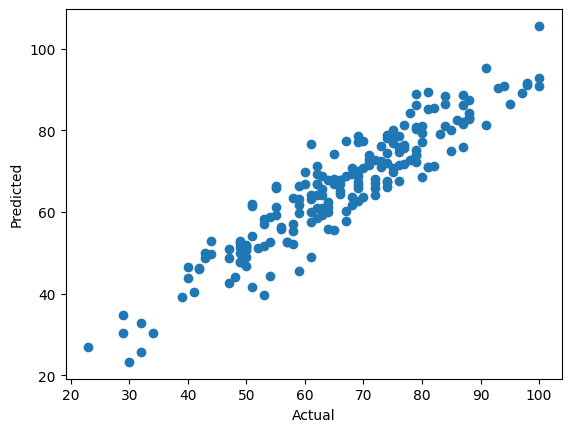

In [17]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

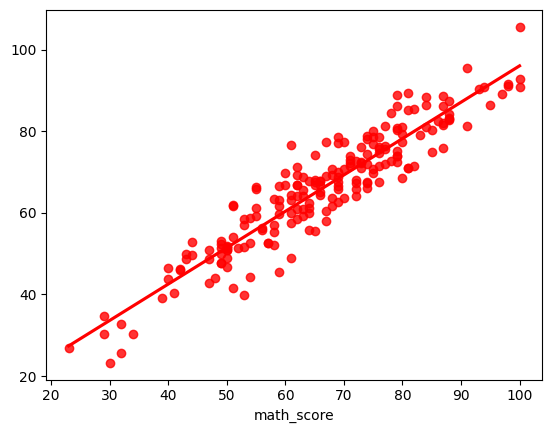

In [18]:
sns.regplot(x=y_test,y=y_pred,ci = None,color = "red")

In [19]:
pred_diff = pd.DataFrame({"Actual Value " : y_test,"Predicted Value" : y_pred , "Difference " : abs(y_pred - y_test)})
pred_diff

,Actual Value,Predicted Value,Difference
131,53,39.736027,13.263973
354,59,63.162628,4.162628
982,79,88.911910,9.911910
476,76,71.514747,4.485253
491,64,61.131744,2.868256
...,...,...,...
819,77,81.199080,4.199080
0,72,65.831518,6.168482
710,93,90.429863,2.570137
889,44,52.940131,8.940131
